In [50]:
import pandas as pd

In [51]:
from google.colab import files

uploaded = files.upload()

Saving bengaluru_house_prices.csv to bengaluru_house_prices (1).csv


In [52]:
Data = pd.read_csv('bengaluru_house_prices.csv')

In [53]:
Data.head(20)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [54]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [55]:
Data.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [56]:
Data.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [57]:
Data.nunique()

,0
area_type,4
availability,81
location,1305
size,31
society,2688
total_sqft,2117
bath,19
balcony,4
price,1994


In [58]:
missing = Data.isnull().sum()
missing_percent = (missing / len(Data)) * 100

pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

,Missing Values,Percentage
area_type,0,0.000000
availability,0,0.000000
location,1,0.007508
size,16,0.120120
society,5502,41.306306
total_sqft,0,0.000000
bath,73,0.548048
balcony,609,4.572072
price,0,0.000000


In [59]:
Data_clean = Data.copy()

In [60]:
Data_clean = Data_clean.drop(['society', 'availability'], axis=1)

In [61]:
Data_clean.head()

,area_type,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [62]:
Data_clean['bhk'] = Data_clean['size'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1162/955531296.py:1: SyntaxWarning: invalid escape sequence '\d'
  Data_clean['bhk'] = Data_clean['size'].str.extract('(\d+)').astype(float)


In [63]:
Data_clean[['size', 'bhk']].head(10)

,size,bhk
0,2 BHK,2.0
1,4 Bedroom,4.0
2,3 BHK,3.0
3,3 BHK,3.0
4,2 BHK,2.0
5,2 BHK,2.0
6,4 BHK,4.0
7,4 BHK,4.0
8,3 BHK,3.0
9,6 Bedroom,6.0


In [64]:
Data_clean.drop('size', axis=1, inplace=True)

In [65]:
Data_clean.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056,2.0,1.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,2600,5.0,3.0,120.00,4.0
2,Built-up Area,Uttarahalli,1440,2.0,3.0,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,1521,3.0,1.0,95.00,3.0
4,Super built-up Area,Kothanur,1200,2.0,1.0,51.00,2.0


In [66]:
Data_clean[~Data_clean['total_sqft'].str.match(r'^\d+(\.\d+)?$', na=False)]['total_sqft'].head(20)

,total_sqft
30,2100 - 2850
56,3010 - 3410
81,2957 - 3450
122,3067 - 8156
137,1042 - 1105
165,1145 - 1340
188,1015 - 1540
224,1520 - 1740
410,34.46Sq. Meter
549,1195 - 1440


In [67]:
def convert_sqft_to_num(x):
    try:
        if '-' in x:
            tokens = x.split('-')
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

In [68]:
Data_clean['total_sqft'] = Data_clean['total_sqft'].apply(convert_sqft_to_num)

In [69]:
Data_clean.isnull().sum()

,0
area_type,0
location,1
total_sqft,46
bath,73
balcony,609
price,0
bhk,16


In [70]:
Data_clean['location'] = Data_clean['location'].fillna('Unknown')
Data_clean['total_sqft'] = Data_clean['total_sqft'].fillna(Data_clean['total_sqft'].median())
Data_clean['bath'] = Data_clean['bath'].fillna(Data_clean['bath'].median())
Data_clean['balcony'] = Data_clean['balcony'].fillna(Data_clean['balcony'].median())
Data_clean['bhk'] = Data_clean['bhk'].fillna(Data_clean['bhk'].median())

In [71]:
Data_clean.isnull().sum()


,0
area_type,0
location,0
total_sqft,0
bath,0
balcony,0
price,0
bhk,0


In [72]:
Data_clean = pd.get_dummies(
    Data_clean,
    columns=['area_type'],
    dtype=int
)

In [73]:
Data_clean.head()

,location,total_sqft,bath,balcony,price,bhk,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0,0,0,0,1
1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0,0,0,1,0
2,Uttarahalli,1440.0,2.0,3.0,62.00,3.0,1,0,0,0
3,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0,0,0,0,1
4,Kothanur,1200.0,2.0,1.0,51.00,2.0,0,0,0,1


In [74]:
location_counts = Data_clean['location'].value_counts()

Data_clean['location'] = Data_clean['location'].apply(
    lambda x: 'other' if location_counts[x] <= 10 else x
)


In [75]:
Data_clean['location'].nunique()

242

In [76]:
Data_clean = pd.get_dummies(
    Data_clean,
    columns=['location'],
    dtype=int
)

In [77]:
Data_clean.head()

,total_sqft,bath,balcony,price,bhk,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_ Devarachikkanahalli,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,1056.0,2.0,1.0,39.07,2.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2600.0,5.0,3.0,120.00,4.0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1440.0,2.0,3.0,62.00,3.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1521.0,3.0,1.0,95.00,3.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,1200.0,2.0,1.0,51.00,2.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [78]:
X = Data_clean.drop('price', axis=1)
y = Data_clean['price']

In [79]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13320, 250)
y shape: (13320,)


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10656, 250)
X_test: (2664, 250)
y_train: (10656,)
y_test: (2664,)


In [82]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (10656, 250)
X_test_scaled shape: (2664, 250)


In [84]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [85]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

In [86]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [87]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 22004.6133 - mae: 75.0802 - val_loss: 22333.9141 - val_mae: 59.8806
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 16131.2402 - mae: 57.1253 - val_loss: 20521.8828 - val_mae: 60.4897
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 14686.0527 - mae: 51.8225 - val_loss: 18980.8887 - val_mae: 51.4414
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13657.1758 - mae: 48.9211 - val_loss: 17881.7383 - val_mae: 47.9602
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12990.7344 - mae: 46.4358 - val_loss: 17200.6914 - val_mae: 49.3741
Epoch 6/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12635.8506 - mae: 44.9868 - val_loss: 16771.0410 - val_mae: 46.5626
Epoch 7/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12282.2793 - mae: 43.6653 - val_loss: 16752.1289 - val_mae: 51.8233
Epoch 8/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11989.2520 - mae: 43.0885 - val_loss: 16495.

In [88]:
test_loss, test_mae = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6502.1338 - mae: 33.6561
Test Loss: 6502.1337890625
Test MAE: 33.656089782714844


In [89]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R² Score: 0.6945998205864766


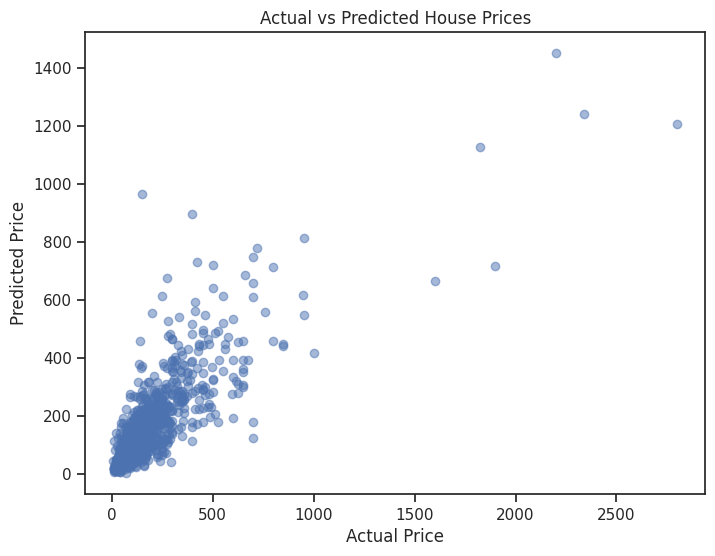

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()